### Project introduction, motivation, and goals

Generative adversarial networks (GANs) are used for image tasks including style transfer, super-resolution, and domain adaptation. CycleGAN extends these possibilities by enabling image-to-image translation without paired training data, with applications in art style conversion, medical imaging, and satellite imagery.

The Monet2Photo model is one of the most widely used pretrained CycleGAN examples, providing an accessible setting to explore how unpaired translation models behave in practice. Even with a pretrained model, important questions arise: How well does it generalize to new paintings? Does translation quality change when applied outside the original training style? Which evaluation methods best capture what the model has learned?

This project serves as a comprehensive case study in evaluating the pretrained Monet2Photo CycleGAN, focusing on two central questions:

1. Model generalization: How does the Monet-trained model perform on unseen Monet test paintings versus paintings from a different artist like Cézanne? While prior work has explored this, we conduct our own systematic evaluation to understand these generalization effects.
2. Evaluation methodology: How do quantitative metrics such as FID, qualitative inspection, and feature space visualizations provide complementary insights into model performance? We investigate situations where metric scores and visual quality diverge.

Our approach follows a structured evaluation framework using established techniques and includes the following steps:
- Apply the pretrained Monet2Photo CycleGAN to test paintings from Monet and Cézanne
- Evaluate translation quality with multiple metrics and compare with literature baselines
- Use visualizations to explore what transformations the model learns
- Discuss metric limitations by contrasting training and test performance

### Expectations for pretrained Monet2Photo CycleGAN

Before running our chosen pretrained Monet2Photo model and evaluating its outputs qualitatively as well as quantitatively, we established the following expectations for the pretrained CycleGAN on the painting-to-photo image translation task.

Functional expectations:
- The model should work as intended and successfully generate output images from input paintings without errors
- The generated images should visually resemble real photographs rather than paintings, e.g., without brush strokes or artistic style elements
- The content of the generated images should maintain the same semantic context and composition as the original paintings

Quality expectations:
- The output quality will be limited by the model's resolution of 256 x 256 pixels, fine details may be lost

Generalization expectations:
- The model should be able to generalize well and create somewhat photo-realistic images from the unseen test data
- When tested against multiple artists, the generated images from Monet paintings should be more realistic than images created from Cezanne paintings as the model was pretrained on Monet paintings

### Setup of pretrained Monet2Photo CycleGAN

To set up the pretrained CycleGAN, we first clone the model's repository and install required libraries.

In [ ]:
# Clone the repository and nanvigate into the directory
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

c:\Users\Yoshio\OneDrive\Bildung\Master (CBS)\Semester-03\Advanced ML for CV\final_project\Advanced-Machine-Learning-for-Computer-Vision\pytorch-CycleGAN-and-pix2pix


Cloning into 'pytorch-CycleGAN-and-pix2pix'...


In [ ]:
# !pip install torch torchvision torchaudio
# !pip install dominate visdom wandb
# !pip install kagglehub

Next, we get the checkpoints for the pretrained model.

In [2]:
import urllib.request
import zipfile
import os

# Create directory
os.makedirs("checkpoints/monet2photo_pretrained", exist_ok=True)

# Download pretrained model
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/monet2photo.pth",
    "checkpoints/monet2photo_pretrained/latest_net_G.pth"
)

('checkpoints/monet2photo_pretrained/latest_net_G.pth',
 <http.client.HTTPMessage at 0x2033df85310>)

Then, the datasets Monet2Photo and Cezanne2Photo are downloaded. Each dataset is saved into a dedicated folder, extracted, and the original zip file is removed to keep the directory clean.

In [4]:
# Download monet2photo
os.makedirs("datasets", exist_ok=True)
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip",
    "datasets/monet2photo.zip"
)
with zipfile.ZipFile("datasets/monet2photo.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")
os.remove("datasets/monet2photo.zip")

In [5]:
# Same for cezanne2photo
urllib.request.urlretrieve(
    "http://efrosgans.eecs.berkeley.edu/cyclegan/datasets/cezanne2photo.zip",
    "datasets/cezanne2photo.zip"
)
with zipfile.ZipFile("datasets/cezanne2photo.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets/")
os.remove("datasets/cezanne2photo.zip")

Now we run the model on unseen test paintings from Monet and paintings from Cezanne.

In [ ]:
# Test on previously unseen Monet paintings
!python test.py --dataroot datasets/monet2photo/testA --name monet2photo_pretrained --model test --no_dropout --num_test 121 --phase test_monet

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo/testA    	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [31]:
# Test on Cézanne paintings
!python test.py --dataroot datasets/cezanne2photo/testA --name monet2photo_pretrained --model test --no_dropout --num_test 525 --phase test_cezanne

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/cezanne2photo/testA  	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

### Qualitative evaluation of the generated images

To be able to compare the input image and the generated image next to each other, the following function is defined.

In [33]:
import matplotlib.pyplot as plt
from PIL import Image

def compare_single_pair(real_path, fake_path, figsize=(12, 6)):
    """ Display one pair of real and fake images side-by-side """
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Load images
    real_img = Image.open(real_path)
    fake_img = Image.open(fake_path)
    
    # Display images
    axes[0].imshow(real_img)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    axes[1].imshow(fake_img)
    axes[1].set_title("Generated")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

First, we take a look at examples for photo-realistic images created from Monet paintings.

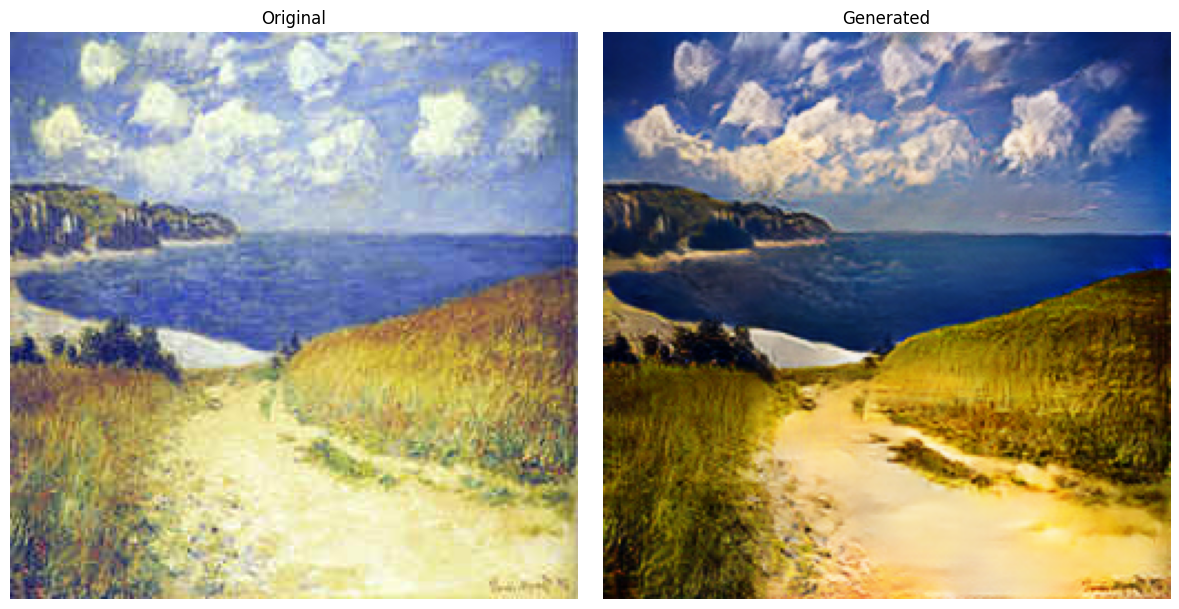

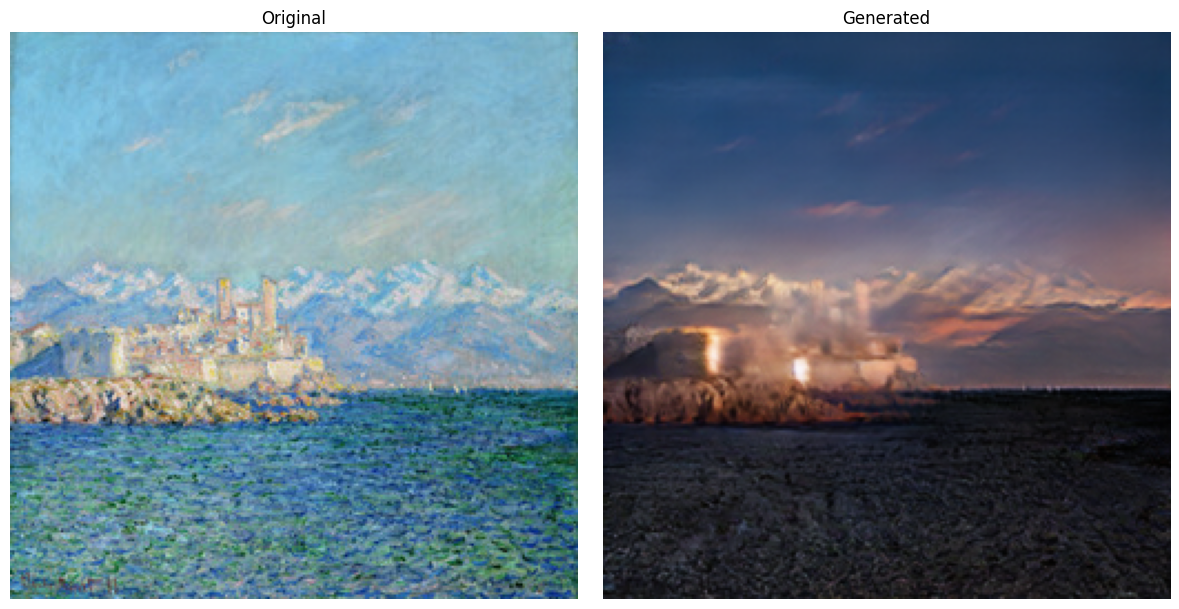

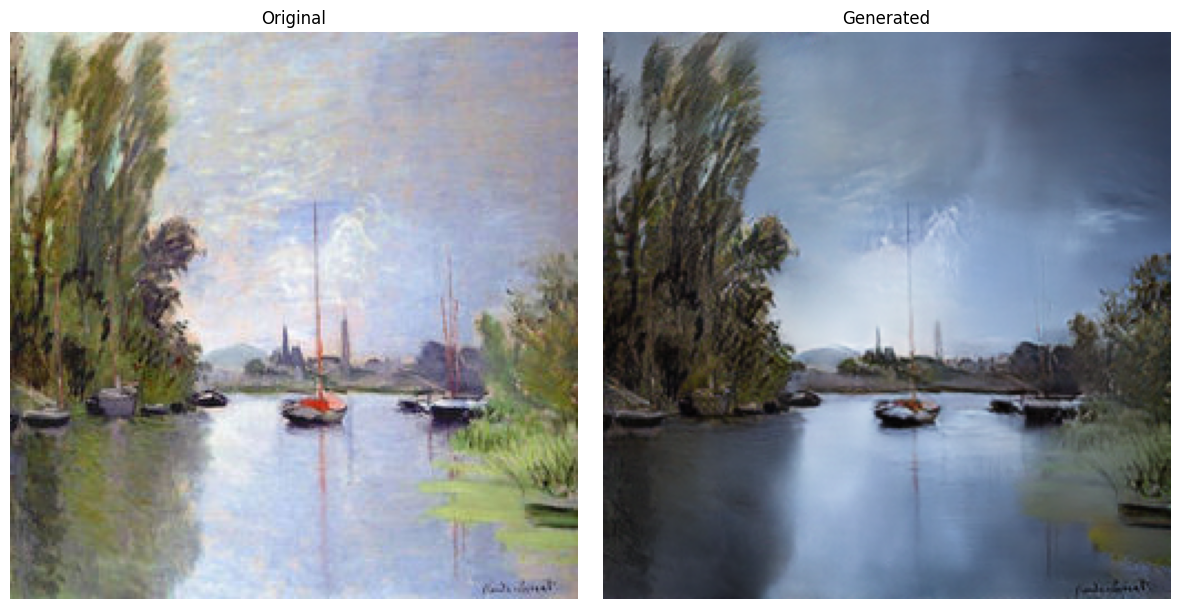

In [9]:
compare_single_pair("results/monet2photo_pretrained/test_monet_latest/images/00010_real.png",
                    "results/monet2photo_pretrained/test_monet_latest/images/00010_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_monet_latest/images/00020_real.png",
                    "results/monet2photo_pretrained/test_monet_latest/images/00020_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_monet_latest/images/00030_real.png",
                    "results/monet2photo_pretrained/test_monet_latest/images/00030_fake.png")

Now, we look at somewhat comparable images generated from Cezanne paintings.

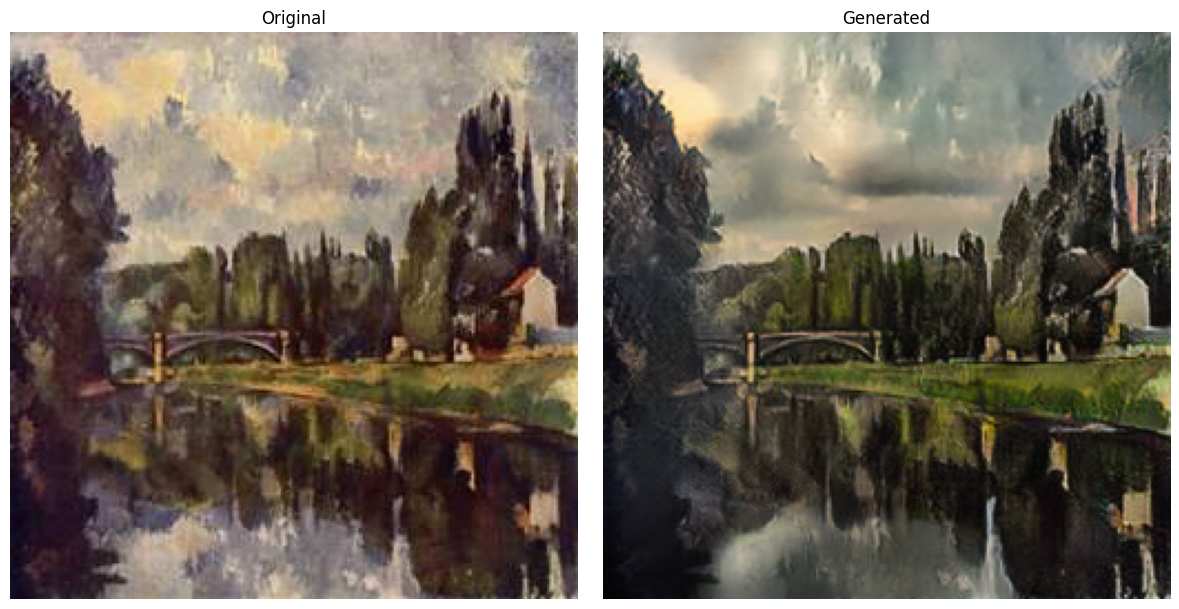

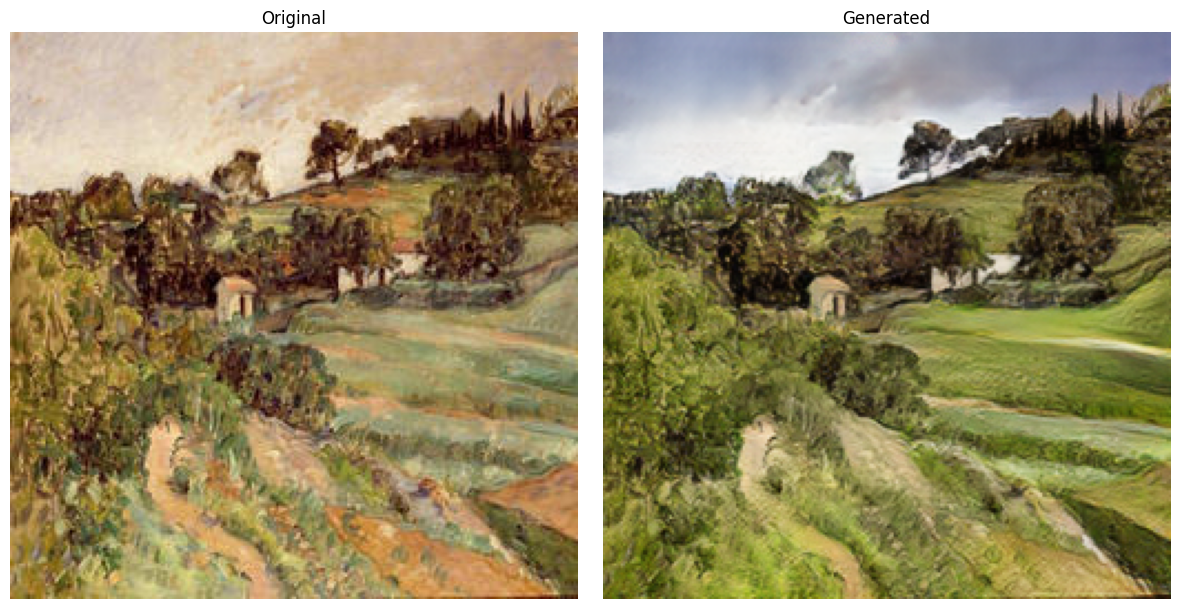

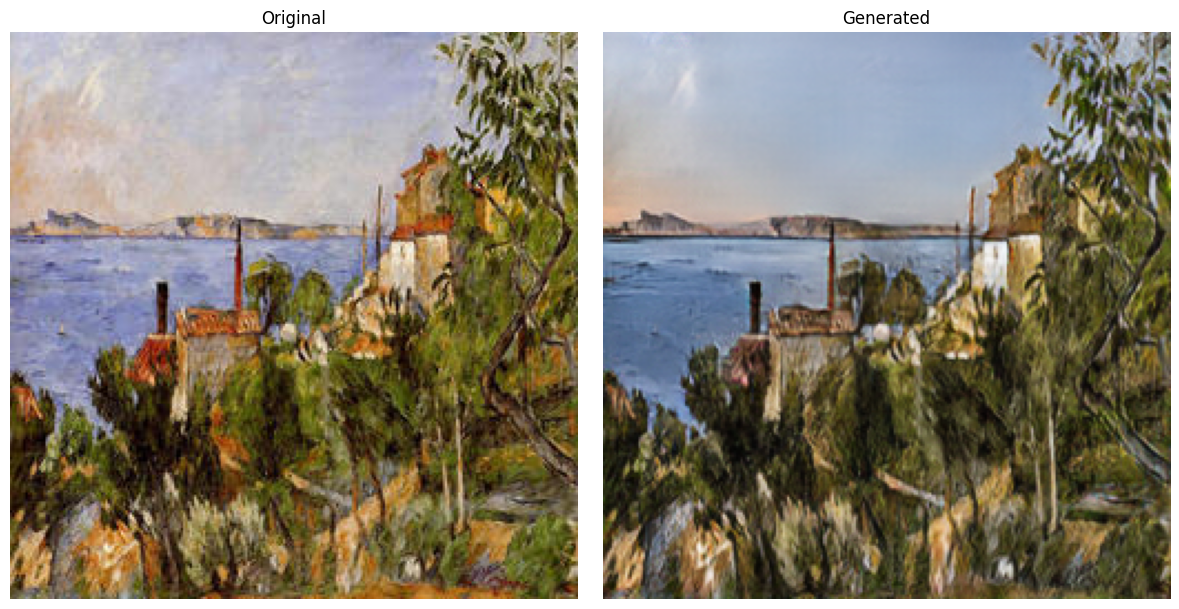

In [35]:
compare_single_pair("results/monet2photo_pretrained/test_cezanne_latest/images/00100_real.png",
                    "results/monet2photo_pretrained/test_cezanne_latest/images/00100_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_cezanne_latest/images/00220_real.png",
                    "results/monet2photo_pretrained/test_cezanne_latest/images/00220_fake.png")

compare_single_pair("results/monet2photo_pretrained/test_cezanne_latest/images/00230_real.png",
                    "results/monet2photo_pretrained/test_cezanne_latest/images/00230_fake.png")

The initial qualitative evaluation confirms the expectations established before running the model:
- The functionality works as intended, the generated images resemble real photographs rather than paintings, and the content maintains the same semantic context and composition as the original paintings
- The quality is limited by the 256 x 256 resolution and the generated images lack sharpness
- The model generalizes well to unseen test data from both artists while images generated from Monet paintings appear more realistic than those from Cezanne paintings

This sets the stage for quantitative evaluation. Since we confirmed the model works as expected, we now want to investigate:
- Whether performance on Monet paintings is comparable to established baselines from literature (Tomei et al. 2018)
- Whether metrics reflect our qualitative observations that Monet samples appear more realistic than Cezanne samples
- How the model performs on test data compared to training data and what this reveals about generalization
- Whether commonly used metrics like FID appropriately capture the translation quality and photorealism we observed visually, and whether alternative metrics like LPIPS provide complementary insights
- Whether feature space visualizations show generated images clustering closer to real photographs than to original paintings, with Monet-generated images positioned closer to the photorealistic domain than Cezanne-generated images

Based on our qualitative observations and the project goals, we expect:
- FID scores for Monet test paintings comparable to literature baselines
- Some performance degradation on test data compared to training data due to smaller sample size and natural generalization gap
- Better metric scores for Monet-generated images compared to Cezanne-generated images
- In feature space visualizations, generated images should position between paintings and real photos, closer to the photorealistic domain, with Monet translations showing stronger movement toward real photos than Cezanne translations

### Quantitative evaluation of the generated images

#### FID:

The FID measures the similarity between two sets of images using deep feautures. It creates a number between 0 and infinity, the lower the number the more identical are the distributions. The score is generated utilizing the pre-existing InceptionNet classifier.

FID has been widely used as it is consistent with human judgement and sensitive to small changes in the real distributions. However, it is important to acknowledge that the FID score suffers from high bias and is more reliable the more inputs are available (50k and more). With our small dataset, the interpretability of the score is therefore limited and can only be seen as a rough estimate. 

To create some kind of comparison, we are comparing the created Monet and Cezanne photos to their real test images.

There is a baseline for the FID score set out by a paper (https://openaccess.thecvf.com/content_ECCVW_2018/papers/11130/Tomei_What_was_Monet_seeing_while_painting_Translating_artworks_to_photo-realistic_ECCVW_2018_paper.pdf#page=12.10), which equals 55.26 on 2048 dimensions. Can we replicate this? If no, why not?

In [30]:
# See how many training images are in the trainA folder

import os
trainA_dir = "datasets/cezanne2photo/trainA"
num_trainA_images = len([f for f in os.listdir(trainA_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
print(f"Number of training images in trainA folder: {num_trainA_images}")

Number of training images in trainA folder: 525


In [ ]:
from glob import glob
import shutil

In [6]:
# Create fake directory in results where only the generated images are shown to compute FID

base_dir = os.getcwd()
source_dir = os.path.join(base_dir, "results/monet2photo_pretrained/test_monet_latest/images")
generated_dir = os.path.join(base_dir, "results/monet2photo_pretrained/test_monet_latest/images_generated")

if os.path.exists(generated_dir):
    shutil.rmtree(generated_dir)
os.makedirs(generated_dir)

In [10]:
# Copy generated images into the new directory

for generated in glob(os.path.join(source_dir, "*_fake.png")):
    shutil.copy(generated, generated_dir)

print(f"{len(glob(os.path.join(generated_dir, "*png")))} images copied.")

121 images copied.


In [29]:
# FID score between generated images and real traning photos as the FID score expects within the same domain

from pytorch_fid import fid_score

fid_value = fid_score.calculate_fid_given_paths(
    ["results/monet2photo_pretrained/test_monet_latest/images_generated",
     "datasets/monet2photo/trainB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 315/315 [08:38<00:00,  1.65s/it]


FID: 117.23


The FID score is way different and they say in the paper that they used 1072, so we try on samples generated from training data.

To be able to have enough generated later, also run the training data trough the model.

Even though this sounds counterintuitive and should not be done for discriminative models, using training data for GAN evaluation is standard practice. Reason is that generative models do not learn input to label mappings but rather learn statistical distributions and never sees the Monet paintings and real images as pairs. The models outputs are always novel and even though they may look the same every time due to the deterministic behaviour of the model, they are not copies from training data.
- The approach will be the following: Test FID score on samples generated from training data and compare the training data of real images.
- Then test on samples generated from test images to see how well the new images perform, keep in mind though that these are very little examples.

Overfitting in GANs shows itself with mode collapse or memorization of training photos, which can be checked through visuali inception and perceptual metrics, and does not happen by using training data for evaluation.

In [23]:
# Test on Monet training data
!python test.py --dataroot datasets/monet2photo/trainA --name monet2photo_pretrained --model test --no_dropout --num_test 1072 --phase train --results_dir results_on_training_data

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/monet2photo/trainA   	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [26]:
# Do the same thing for the samples generated from the training images

source_dir_train_monet = os.path.join(base_dir, "results_on_training_data/monet2photo_pretrained/train_latest/images")
generated_dir_train_monet = os.path.join(base_dir, "results_on_training_data/monet2photo_pretrained/train_latest/images_generated")

if os.path.exists(generated_dir_train_monet):
    shutil.rmtree(generated_dir_train_monet)
os.makedirs(generated_dir_train_monet)

# Copy generated images into the new directory

for generated in glob(os.path.join(source_dir_train_monet, "*_fake.png")):
    shutil.copy(generated, generated_dir_train_monet)

print(f"{len(glob(os.path.join(generated_dir_train_monet, "*png")))} images copied.")

1072 images copied.


In [27]:
# FID score between generated images and real traning photos as the FID score expects within the same domain

from pytorch_fid import fid_score

fid_value = fid_score.calculate_fid_given_paths(
    ["results_on_training_data/monet2photo_pretrained/train_latest/images_generated",
     "datasets/monet2photo/trainB"],
    batch_size=20,
    device="cpu",
    dims=2048
)

print(f"FID: {fid_value:.2f}")

100%|██████████| 315/315 [09:04<00:00,  1.73s/it]


FID: 48.15


The FID score is now comparable to what is observed in Tomei et al. (2018), and ours is even slightly better. Why the difference? We are comparing against a different real image dataset than the paper. Tomei et al. used 2048 photos collected from Flickr with tags "landscape" and "landscapephotography". Our real images come from the monet2photo dataset's trainB and testB sets, which on one hand includes more pictures (~6000+) and can therefore more reliably estimate the distribution, and on the other hand was specifically curated to be semantically aligned with Monet's subject matter. Nonetheless, this demonstrates that our CycleGAN model performs as intended for the painting-to-photo translation task, compared to previous users.

The lower FID in our evaluation likely reflects that the monet2photo dataset contains photos that are more semantically compatible with Monet's paintings (similar scenes and compositions), making it a more appropriate baseline for assessing translation quality on this specific task.

Why do the results differ? Are we having the same number of pictures? For both domains? On the one hand, the generated images, on the other hand, the real images? What are the real images for them? Can we find them too and try to run the evaulation with them?

As stated before, the FID score has its flaws. What are other options to quantify our results? Is this even useful? Or should we only embedd and look at these visualizations?

Why is the FID score for the test images worse? What does this tell us about the FID score? What else can we employ to test whether the model generalizes well on Monet paintings? Create embeddings of both the samples generated fromt training and the samples generated from test Monet paintings and compare the distance? Use any other metric?

#### LPIPS (Learned Perceptual Image Patch Similarity):

Look at last paper in downloads and figure out what this says...

In [ ]:
import lpips

# Install: pip install lpips

# Initialize (use 'alex' or 'vgg')
loss_fn = lpips.LPIPS(net='alex')  # or net='vgg'

# Calculate LPIPS between two images
import torch
from PIL import Image
import torchvision.transforms as transforms

def calc_lpips(img1_path, img2_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    img1 = transform(Image.open(img1_path)).unsqueeze(0)
    img2 = transform(Image.open(img2_path)).unsqueeze(0)
    
    distance = loss_fn(img1, img2)
    return distance.item()

# Average LPIPS across your dataset
distances = []
for gen_img, real_img in zip(generated_paths, real_paths):
    distances.append(calc_lpips(gen_img, real_img))

avg_lpips = sum(distances) / len(distances)
print(f"Average LPIPS: {avg_lpips:.4f}")

In [ ]:
# Compare generated photo to its corresponding real photo
lpips_distance = calc_lpips(generated_photo, real_photo)
# Lower = generated looks more like a real photo

In [ ]:
# 1. Monet → Photo (generated)
# 2. Photo → Monet (reconstructed)
# Compare: original Monet vs reconstructed Monet

lpips_cycle = calc_lpips(original_monet, reconstructed_monet)
# Lower = better cycle consistency (content preservation)

#### SSIM:

SSIM measures image quality by comparing local patterns of luminance, contrast, and structure between two images, reflecting how humans perceive structural changes rather than raw pixel error. Original SSIM paper can be found here: https://www.cns.nyu.edu/pub/lcv/wang03-reprint.pdf

We are calculating SSIM measure to get a first indication how much the original Monet image changed compared to its photorealistic counterpart (the output of the GAN). SSIM assumes pairs as it looks at considers three things (taken from: https://medium.com/@akp83540/structural-similarity-index-ssim-c5862bb2b520):

- *Brightness*: How bright are the pictures overall? Is one picture really dark and the other one really bright?
- *Contrast*: How different are the colors next to each other in the pictures? Are the colors in one picture washed out compared to the other?
- *Structure*: Are the patterns and shapes in the same places in both pictures? If one picture is blurry, the SSIM would take that into account.

In [7]:
# Paste SSIM code here

#### CLIP Embeddings?

#### 3D visualization?

## Quantitative Evaluation: FID Score

We first evaluate the model using the Fréchet Inception Distance (FID) score, a standard metric for assessing generative model quality that measures the distance between feature distributions of generated and real images.

### Test Set Results

| Dataset | Generated Images | Real Images | FID Score |
|---------|-----------------|-------------|-----------|
| Monet test | 121 | 6000+ | 121.62 |
| Cezanne test | XXX | 6000+ | XXX |

The FID score of 121.62 for Monet test paintings appears significantly higher than the baseline reported by Tomei et al. (2018), who achieved an FID of 55.26 for CycleGAN on similar painting-to-photo translation.

### Training Set Comparison

Upon closer inspection of the literature, we note that Tomei et al. computed FID on their full training set (1072 Monet paintings). To ensure a fair comparison, we evaluate our model on the training set as well:

| Dataset | Generated Images | Real Images | FID Score |
|---------|-----------------|-------------|-----------|
| Monet training | 1072 | 6000+ | 48.15 |
| Monet test | 121 | 6000+ | 121.62 |

Our training FID of 48.15 is actually better than the literature baseline of 55.26. This improvement can be attributed to our use of the curated monet2photo dataset, where real photos are semantically aligned with Monet's subject matter, compared to Tomei et al.'s random Flickr landscape collection.

However, the 2.5× increase from training (48.15) to test (121.62) reveals critical limitations of FID as an evaluation metric.

## Limitations of FID Score

The dramatic difference between training and test FID highlights several fundamental issues with FID:

**Sample size sensitivity:**
- Training comparison: 1072 vs 6000+ images (ratio ~1:6)
- Test comparison: 121 vs 6000+ images (ratio ~1:50)
- FID estimates covariance matrices in high-dimensional feature space (2048-d), which requires substantial sample sizes for stability
- With only 121 test images, the covariance estimate is unreliable

**Distribution vs quality mismatch:**
- FID measures whether two distributions match statistically, not whether individual images are photorealistic
- Even if all 121 test images are visually excellent, FID penalizes any statistical divergence from the 6000+ real photo distribution
- Our qualitative evaluation showed good visual quality, yet FID suggests poor performance

**No absolute interpretation:**
- Is 48.15 "good"? Is 121.62 "bad"? FID provides no meaningful thresholds
- Different sample sizes produce incomparable FID values
- The metric cannot distinguish between "poor generation" and "small sample size"

These limitations demonstrate that FID alone is insufficient for evaluating image translation quality and motivates our exploration of complementary metrics.

## Alternative Evaluation Metrics

To address FID's limitations, we explore additional metrics that capture different aspects of translation quality:

[Your exploration of LPIPS and other metrics]

## Feature Space Visualization

Finally, we employ dimensionality reduction techniques to visualize where generated images fall in feature space relative to paintings and real photos:

[Your t-SNE/UMAP visualization with paintings, generated images, and real photos]

This visualization provides intuitive evidence of whether the model successfully translates paintings toward the photorealistic domain.